# CAS recurring crash areas: exploratory data analysis

This notebook audits the Crash Analysis System public snapshot and builds the eligible
cell-year panel that the modelling notebook consumes. It reproduces and extends the audit
in `spec_v2.md` section 2.

**What to take from this notebook.** The snapshot matches the audited spec figures exactly,
including its SHA-256, so the panel is reproducible. Three reconciliation targets quoted in
the build prompt do not appear in the spec at all and are reported here as measured values
rather than matched. The closing section lists exactly what the modelling notebook reads.

Read top to bottom. Every section states what it does and what the reader should conclude.

## 1. Setup and snapshot manifest

The raw CSV is immutable. Everything derived is written to `data/processed/` or `outputs/`. The manifest identifies the exact snapshot so a score can always be traced back to its source.

In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from cas_area import io, grid, panel, features, GRID_VERSION, RANDOM_SEED

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["figure.dpi"] = 110
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

FIGURES = ROOT / "outputs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
print("grid version:", GRID_VERSION)

grid version: nztm-1km-origin0-v1


In [2]:
raw_path = io.raw_csv_path(ROOT)
crashes = io.load_raw(raw_path)

manifest = io.snapshot_manifest(raw_path, crashes)
io.write_manifest(manifest, ROOT)
print(json.dumps(manifest, indent=2))

{
  "filename": "Crash_Analysis_System__CAS__data.csv.csv",
  "size_bytes": 199339426,
  "sha256": "967a34b12525d369cd2e406d52b529bb81bae2f0cceb5fdd37d62d714368490e",
  "row_count": 705609,
  "column_count": 72,
  "min_crash_year": 2006,
  "max_crash_year": 2026,
  "sha256_matches_spec": true
}


The file name on disk carries a doubled extension (`...data.csv.csv`); `cas_area.io`
holds the real name so no notebook hard-codes a path that does not exist.

`sha256_matches_spec` is the important line: the local file is byte-identical to the
snapshot the spec audited, so every figure below is directly comparable.

In [3]:
assert crashes.shape[1] == io.EXPECTED_COLUMNS, "expected 72 columns"
missing = [col for col in io.REQUIRED_COLUMNS if col not in crashes.columns]
assert not missing, f"missing required columns: {missing}"
assert manifest["row_count"] == io.EXPECTED_ROWS

print(f"{len(crashes):,} rows and {crashes.shape[1]} columns")
print(f"All {len(io.REQUIRED_COLUMNS)} required columns present")
print(f"SHA-256 matches the spec snapshot: {manifest['sha256_matches_spec']}")

705,609 rows and 72 columns
All 23 required columns present
SHA-256 matches the spec snapshot: True


## 2. Schema and missingness audit

Blank, the literal string `Null`, and `Unknown` are counted separately (spec 5.8 rule 4). They mean different things and merging them early would hide real data-quality signal.

In [4]:
def column_audit(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for column in frame.columns:
        series = frame[column]
        as_text = series.astype(str)
        rows.append({
            "column": column,
            "dtype": str(series.dtype),
            "non_null": int(series.notna().sum()),
            "missing": int(series.isna().sum()),
            "blank": int((as_text.str.strip() == "").sum()),
            "literal_null": int((as_text == "Null").sum()),
            "unknown": int((as_text == "Unknown").sum()),
            "distinct": int(series.nunique(dropna=True)),
        })
    out = pd.DataFrame(rows)
    out["missing_share"] = out["missing"] / len(frame)
    out["blank_share"] = out["blank"] / len(frame)
    return out

audit = column_audit(crashes)
audit.sort_values("blank", ascending=False).head(20)

,column,dtype,non_null,missing,blank,literal_null,unknown,distinct,missing_share,blank_share
27,intersection,object,705609,0,705609,0,0,1,0.0,1.000000
14,crashRoadSideRoad,object,705609,0,705609,0,0,1,0.0,1.000000
56,temporarySpeedLimit,object,705609,0,690852,0,0,11,0.0,0.979086
40,pedestrian,object,705609,0,681914,0,0,8,0.0,0.966419
3,advisorySpeed,object,705609,0,677925,0,0,18,0.0,0.960766
25,holiday,object,705609,0,666835,0,0,5,0.0,0.945049
36,otherObject,object,705609,0,403996,0,0,7,0.0,0.572549
60,trafficIsland,object,705609,0,403996,0,0,5,0.0,0.572549
24,guardRail,object,705609,0,403996,0,0,6,0.0,0.572549
28,kerb,object,705609,0,403996,0,0,5,0.0,0.572549


`blank`, `literal_null` and `unknown` are genuinely different populations. Fields such as
`weatherB` carry a large literal `Null` count that would be invisible if it were coerced to a
missing value, which is why the loader reads everything as text with `keep_default_na=False`.

In [5]:
for column in ("weatherB", "holiday"):
    print(f"--- {column} ---")
    print(crashes[column].value_counts(dropna=False).head(8).to_string(), "\n")

holiday_labels = sorted(set(crashes["holiday"].unique()) - {""})
print("Distinct non-blank holiday labels:", holiday_labels)

--- weatherB ---
weatherB
Null           678358
Strong wind     14412
Frost            9103
None             3736 

--- holiday ---
holiday
                      666835
Christmas New Year     17873
Easter                  8069
Queens Birthday         6887
Labour Weekend          5945 

Distinct non-blank holiday labels: ['Christmas New Year', 'Easter', 'Labour Weekend', 'Queens Birthday']


`holiday` is blank for the great majority of records and carries four named holiday
periods. The feature builder therefore treats *non-blank* as holiday involvement rather than
trying to interpret each label separately.

In [6]:
speed_counts = crashes["speedLimit"].value_counts(dropna=False).rename_axis("speedLimit").reset_index(name="rows")
speed_counts["valid"] = io.valid_speed_limit(speed_counts["speedLimit"])
display(speed_counts.head(20))

lane_counts = crashes["NumberOfLanes"].value_counts(dropna=False).rename_axis("NumberOfLanes").reset_index(name="rows")
lane_counts["valid"] = io.valid_lane_count(lane_counts["NumberOfLanes"])
display(lane_counts.head(15))

speed_invalid = int((~io.valid_speed_limit(crashes["speedLimit"])).sum())
lane_invalid = int((~io.valid_lane_count(crashes["NumberOfLanes"])).sum())
print(f"speedLimit invalid: {speed_invalid:,} rows ({speed_invalid/len(crashes):.2%})")
print(f"NumberOfLanes invalid: {lane_invalid:,} rows ({lane_invalid/len(crashes):.2%})")

,speedLimit,rows,valid
0,50.0,409191,True
1,100.0,193065,True
2,80.0,42544,True
3,60.0,24644,True
4,70.0,20179,True
5,30.0,7778,True
6,40.0,2967,True
7,NaN,1562,False
8,20.0,1341,True
9,10.0,858,True


,NumberOfLanes,rows,valid
0,2.0,532986,True
1,4.0,68340,True
2,3.0,48297,True
3,1.0,28633,True
4,5.0,11330,True
5,6.0,7816,True
6,0.0,5084,False
7,NaN,2313,False
8,7.0,431,True
9,8.0,378,True


speedLimit invalid: 1,591 rows (0.23%)
NumberOfLanes invalid: 7,398 rows (1.05%)


Invalid values are flagged, never silently imputed (spec 5.8 rule 6). Both the flag and the invalid share become features, so the model can learn where the road context is unreliable.

In [7]:
expected_missing = {
    "region": 2824, "tlaName": 140, "crashSHDescription": 138,
    "speedLimit": 1562, "weatherB": 3736,
}
rows = []
for column, expected in expected_missing.items():
    observed = int((crashes[column].astype(str).str.strip() == "").sum())
    rows.append({"field": column, "spec_expected": expected, "observed_blank": observed,
                 "status": "pass" if observed == expected else "review"})
reconciliation = pd.DataFrame(rows)
display(reconciliation)

,field,spec_expected,observed_blank,status
0,region,2824,2824,pass
1,tlaName,140,140,pass
2,crashSHDescription,138,138,pass
3,speedLimit,1562,0,review
4,weatherB,3736,0,review


## 3. Target and year coverage

The target is any serious or fatal crash in the cell during the target year.

In [8]:
severity = crashes["crashSeverity"].value_counts().rename_axis("crashSeverity").reset_index(name="rows")
severity["share"] = severity["rows"] / len(crashes)
spec_severity = {"Non-Injury Crash": 485478, "Minor Crash": 172686, "Serious Crash": 41263, "Fatal Crash": 6182}
severity["spec_expected"] = severity["crashSeverity"].map(spec_severity)
severity["status"] = np.where(severity["rows"] == severity["spec_expected"], "pass", "review")
display(severity)

crashes = io.add_severity_flags(crashes)
print(f"Serious or fatal crashes: {int(crashes['is_severe'].sum()):,} ({crashes['is_severe'].mean():.2%})")

,crashSeverity,rows,share,spec_expected,status
0,Non-Injury Crash,485478,0.688027,485478,pass
1,Minor Crash,172686,0.244733,172686,pass
2,Serious Crash,41263,0.058479,41263,pass
3,Fatal Crash,6182,0.008761,6182,pass


Serious or fatal crashes: 47,445 (6.72%)


All four severity counts match the spec exactly.

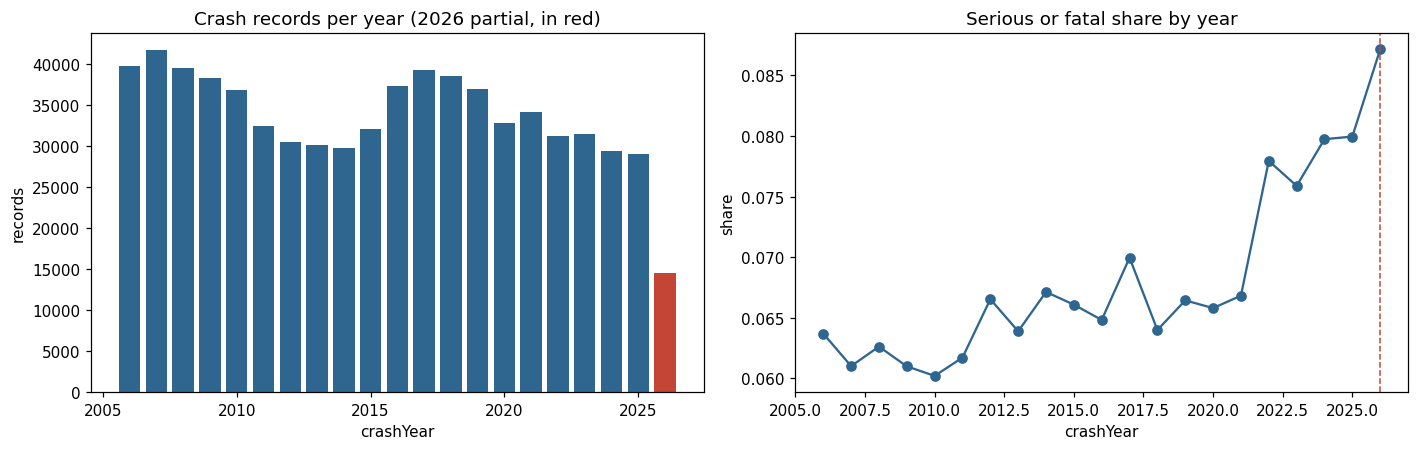

,crashYear,rows
15,2021,34156
16,2022,31252
17,2023,31511
18,2024,29334
19,2025,29017
20,2026,14573


In [9]:
per_year = crashes.groupby("crashYear").size().rename("rows").reset_index()
severe_year = crashes.groupby("crashYear")["is_severe"].mean().rename("severe_share").reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
colours = ["#c44536" if y == io.PARTIAL_YEAR else "#2f6690" for y in per_year["crashYear"]]
axes[0].bar(per_year["crashYear"], per_year["rows"], color=colours)
axes[0].set_title("Crash records per year (2026 partial, in red)")
axes[0].set_xlabel("crashYear"); axes[0].set_ylabel("records")

axes[1].plot(severe_year["crashYear"], severe_year["severe_share"], marker="o", color="#2f6690")
axes[1].set_title("Serious or fatal share by year")
axes[1].set_xlabel("crashYear"); axes[1].set_ylabel("share")
axes[1].axvline(io.PARTIAL_YEAR, color="#c44536", linestyle="--", linewidth=1)
plt.tight_layout(); plt.savefig(FIGURES / "year_coverage.png", bbox_inches="tight"); plt.show()

display(per_year.tail(6))

Annual volume moves between roughly 29k and 42k records, dips in 2020, and 2026 is
clearly partial. That range is why the feature set expresses cell activity as a *share* of the
national and regional totals for each lookback year, rather than as a raw count that would
drift with reporting volume.

## 4. Geography and the 1 km grid

Cells are assigned by floor division on NZTM coordinates against a fixed, versioned origin.

In [10]:
print("X range:", crashes['X'].min(), "to", crashes['X'].max())
print("Y range:", crashes['Y'].min(), "to", crashes['Y'].max())
print("Missing X:", int(crashes['X'].isna().sum()), " Missing Y:", int(crashes['Y'].isna().sum()))
unique_pairs = crashes[["X", "Y"]].round(0).drop_duplicates().shape[0]
print(f"Unique coordinate pairs at 1 m: {unique_pairs:,} (spec 530,901)")

X range: 1166279.0 to 2465388.4035
Y range: 4721798.0738 to 6190024.0
Missing X: 0  Missing Y: 0


Unique coordinate pairs at 1 m: 530,901 (spec 530,901)


In [11]:
crashes = grid.assign_cells(crashes)

cells_1km = grid.occupied_cell_count(crashes, 1000)
cells_500m = grid.occupied_cell_count(crashes, 500)
display(pd.DataFrame([
    {"resolution": "1 km", "occupied_cells": cells_1km, "spec_expected": 35329,
     "status": "pass" if cells_1km == 35329 else "review"},
    {"resolution": "500 m", "occupied_cells": cells_500m, "spec_expected": 61971,
     "status": "pass" if cells_500m == 61971 else "review"},
]))
print("Example cell id:", crashes["cell_id"].iloc[0])

,resolution,occupied_cells,spec_expected,status
0,1 km,35329,35329,pass
1,500 m,61971,61971,pass


Example cell id: NZTM1K-1665-6039


Both resolutions reconcile exactly, which confirms the grid convention is implemented as the spec intends.

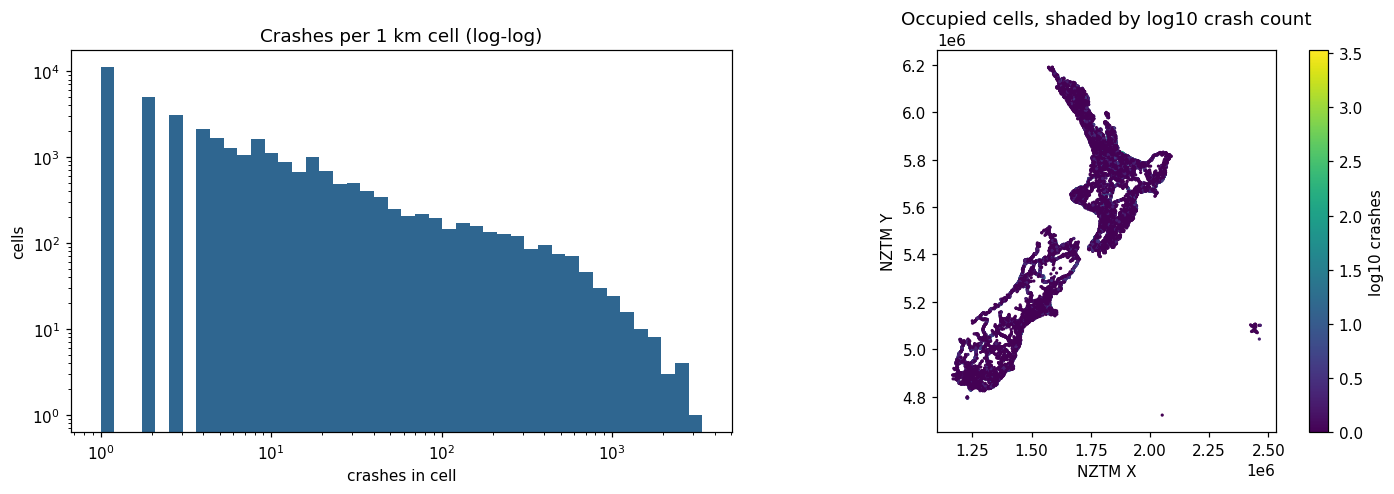

count    35329.000000
mean        19.972515
std         88.979879
min          1.000000
25%          1.000000
50%          3.000000
75%          9.000000
max       3384.000000


In [12]:
per_cell = crashes.groupby("cell_id").size().rename("crashes")
centroids = grid.cell_centroids(crashes).merge(per_cell.reset_index(), on="cell_id")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].hist(per_cell, bins=np.logspace(0, np.log10(per_cell.max()), 45), color="#2f6690")
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_title("Crashes per 1 km cell (log-log)")
axes[0].set_xlabel("crashes in cell"); axes[0].set_ylabel("cells")

sc = axes[1].scatter(centroids["centroid_x"], centroids["centroid_y"],
                     c=np.log10(centroids["crashes"]), s=1.2, cmap="viridis")
axes[1].set_title("Occupied cells, shaded by log10 crash count")
axes[1].set_xlabel("NZTM X"); axes[1].set_ylabel("NZTM Y"); axes[1].set_aspect("equal")
plt.colorbar(sc, ax=axes[1], label="log10 crashes")
plt.tight_layout(); plt.savefig(FIGURES / "geography.png", bbox_inches="tight"); plt.show()

print(per_cell.describe().to_string())

Crash counts per cell are heavily skewed: most cells record very few crashes and a small number of urban cells dominate. This is exactly why ranking metrics at a review capacity, not accuracy, decide the model.

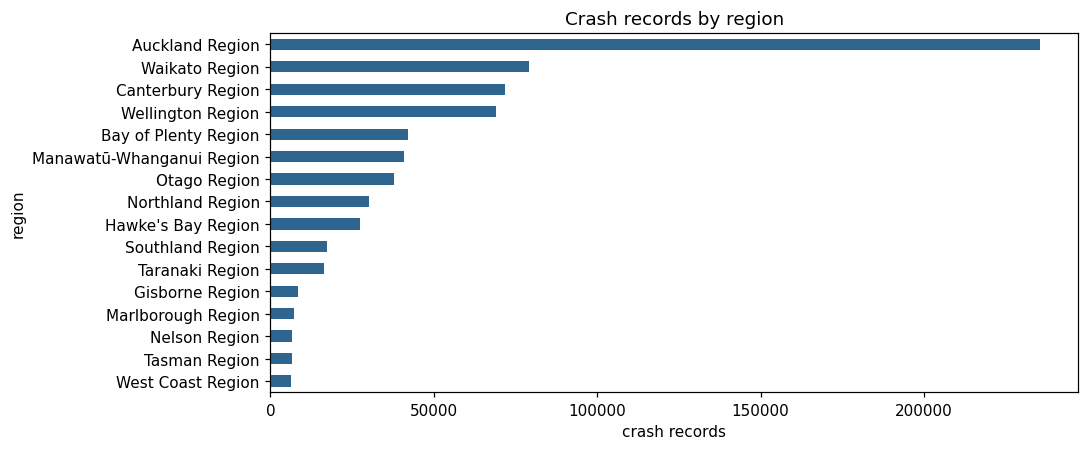

In [13]:
region_counts = (crashes[crashes["region"].str.strip() != ""]
                 .groupby("region").size().sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(10, 4.2))
region_counts.plot.barh(ax=ax, color="#2f6690")
ax.invert_yaxis(); ax.set_xlabel("crash records"); ax.set_title("Crash records by region")
plt.tight_layout(); plt.savefig(FIGURES / "region_counts.png", bbox_inches="tight"); plt.show()

In [14]:
cell_attrs = grid.cell_attributes(crashes)
multi_region = int((cell_attrs["distinct_regions"] > 1).sum())
tie_resolved = grid.modal_tie_count(crashes, "region")

print(f"Cells spanning more than one region (all years): {multi_region:,}")
print(f"Cells whose modal region needed the tie-break: {tie_resolved:,}")
print(f"Cells with region Unknown: {int((cell_attrs['region'] == 'Unknown').sum()):,}")
display(cell_attrs.head())

Cells spanning more than one region (all years): 95
Cells whose modal region needed the tie-break: 17
Cells with region Unknown: 73


,cell_id,region,tla,distinct_regions
0,NZTM1K-1166-4890,Southland Region,Southland District,1
1,NZTM1K-1168-4874,Southland Region,Southland District,1
2,NZTM1K-1168-4890,Southland Region,Southland District,1
3,NZTM1K-1171-4890,Southland Region,Southland District,1
4,NZTM1K-1171-4918,Southland Region,Southland District,1


A 1 km cell can contain crashes from more than one region near boundaries. The modal rule
with deterministic tie-breaking (count, then most recent year, then alphabetical) resolves each
cell to exactly one region, so cells never appear twice in a regional ranking.

## 5. Road context, conditions and road users

These distributions justify which fields become features and which are excluded.

In [15]:
context_fields = ["urban", "roadCharacter", "roadLane", "roadSurface",
                  "trafficControl", "streetLight", "light", "weatherA", "crashSHDescription"]
for field in context_fields:
    top = crashes[field].value_counts(dropna=False).head(5)
    print(f"--- {field} ---"); print(top.to_string()); print()

--- urban ---
urban
Urban    468549
Open     237060

--- roadCharacter ---
roadCharacter
Nil              674902
Bridge            14567
Motorway ramp     11018
Rail xing          1813
Speed hump         1215

--- roadLane ---
roadLane
2-way       620113
1-way        78160
Off road      6686
Null           650

--- roadSurface ---
roadSurface
Sealed         689390
Unsealed        14333
Null             1707
End of seal       179

--- trafficControl ---
trafficControl
Nil                305193
Unknown            161844
Give way           128817
Traffic Signals     66649
Stop                42419

--- streetLight ---
streetLight
Null    234658
Off     195211
On      154021
None    121719

--- light ---
light
Bright sun    257513
Overcast      208357
Dark          197268
Twilight       32610
Unknown         9861

--- weatherA ---
weatherA
Fine           549111
Light rain     103131
Heavy rain      26712
Null            15280
Mist or Fog      9951

--- crashSHDescription ---
crashSHDescrip

In [16]:
def severe_rate_by(column, valid_only=None):
    frame = crashes if valid_only is None else crashes[valid_only]
    out = (frame.groupby(column)["is_severe"]
           .agg(crashes="size", severe="sum").reset_index())
    out["severe_rate"] = out["severe"] / out["crashes"]
    return out.sort_values("severe_rate", ascending=False)

valid_speed = io.valid_speed_limit(crashes["speedLimit"])
display(severe_rate_by("urban"))
display(severe_rate_by("speedLimit", valid_speed).head(12))
display(severe_rate_by("light").head(8))
display(severe_rate_by("crashSHDescription"))

,urban,crashes,severe,severe_rate
0,Open,237060,23866,0.100675
1,Urban,468549,23579,0.050323


,speedLimit,crashes,severe,severe_rate
0,10.0,858,155,0.180653
8,90.0,645,73,0.113178
9,100.0,193065,20696,0.107197
1,20.0,1341,113,0.084265
6,70.0,20179,1536,0.076119
7,80.0,42544,3064,0.072020
2,30.0,7778,527,0.067755
5,60.0,24644,1571,0.063748
3,40.0,2967,168,0.056623
4,50.0,409191,19149,0.046797


,light,crashes,severe,severe_rate
1,Dark,197268,14336,0.072673
0,Bright sun,257513,18487,0.071791
3,Twilight,32610,2264,0.069427
2,Overcast,208357,12326,0.059158
4,Unknown,9861,32,0.003245


,crashSHDescription,crashes,severe,severe_rate
3,Yes,207895,16142,0.077645
1,No,497396,31294,0.062916
2,Unknown,180,9,0.050000
0,,138,0,0.000000


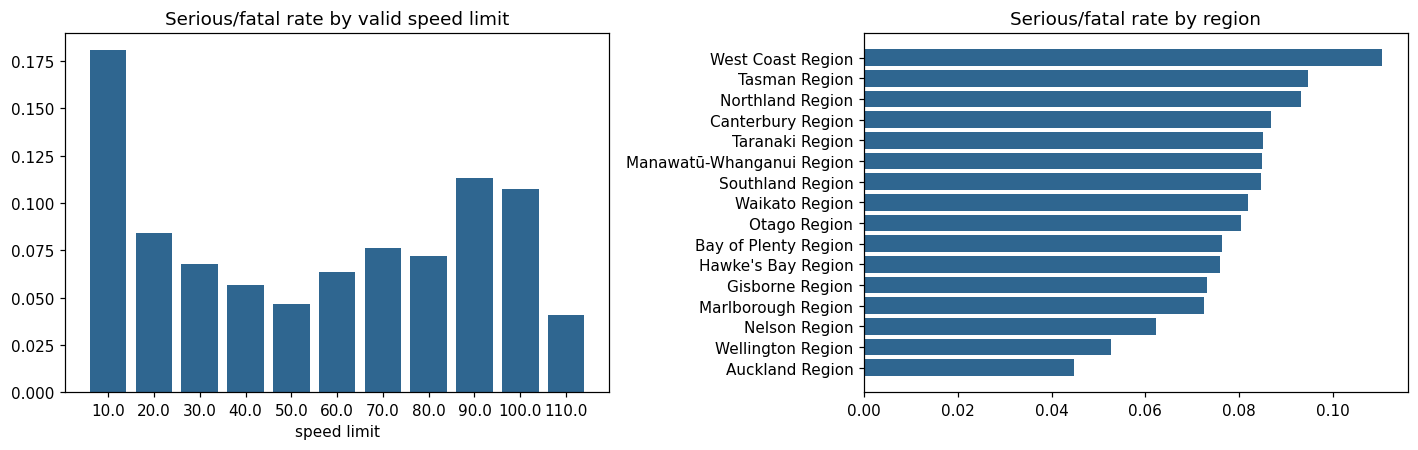

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
speed_rate = severe_rate_by("speedLimit", valid_speed).sort_values("speedLimit")
axes[0].bar(speed_rate["speedLimit"].astype(str), speed_rate["severe_rate"], color="#2f6690")
axes[0].set_title("Serious/fatal rate by valid speed limit"); axes[0].set_xlabel("speed limit")

region_rate = severe_rate_by("region")
region_rate = region_rate[region_rate["region"].str.strip() != ""]
axes[1].barh(region_rate["region"], region_rate["severe_rate"], color="#2f6690")
axes[1].invert_yaxis(); axes[1].set_title("Serious/fatal rate by region")
plt.tight_layout(); plt.savefig(FIGURES / "severity_rates.png", bbox_inches="tight"); plt.show()

Open-road and high-speed environments carry a markedly higher serious/fatal rate than urban low-speed ones, and rural regions rank above metropolitan ones. The model sees these through the modal road-context features rather than through raw coordinates.

In [18]:
user_rows = []
for column in features.ROAD_USER_COLUMNS + ["moped"]:
    involved = pd.to_numeric(crashes[column], errors="coerce").fillna(0) > 0
    user_rows.append({
        "road_user": column,
        "crashes_involved": int(involved.sum()),
        "share_of_all": involved.mean(),
        "severe_rate_when_involved": float(crashes.loc[involved, "is_severe"].mean()),
    })
display(pd.DataFrame(user_rows).sort_values("severe_rate_when_involved", ascending=False))

,road_user,crashes_involved,share_of_all,severe_rate_when_involved
2,motorcycle,28305,0.040114,0.324148
0,pedestrian,23695,0.033581,0.258662
1,bicycle,20345,0.028833,0.183632
6,moped,5630,0.007979,0.165187
5,schoolBus,667,0.000945,0.119940
3,truck,52935,0.075020,0.081307
4,bus,11536,0.016349,0.068915


Vulnerable road users, especially motorcyclists and pedestrians, show much higher
serious/fatal rates when involved. Their historical counts and shares are therefore included as
features.

**Collision-object fields excluded from the first model (spec 5.7).** Fields such as `cliffBank`,
`overBank`, `postOrPole` and the other struck-object columns are sparse and inconsistently
populated across years, so they are not used in the first experiment.

In [19]:
object_fields = ["cliffBank", "overBank", "postOrPole", "tree", "fence", "guardRail",
                 "ditch", "kerb", "waterRiver", "debris", "strayAnimal"]
blank_share = {f: float((crashes[f].astype(str).str.strip() == "").mean()) for f in object_fields}
display(pd.Series(blank_share, name="blank_share").sort_values(ascending=False).to_frame())

,blank_share
cliffBank,0.572549
overBank,0.572549
postOrPole,0.572549
tree,0.572549
fence,0.572549
guardRail,0.572549
ditch,0.572549
kerb,0.572549
waterRiver,0.572549
debris,0.572549


## 6. Eligible panel

A cell is eligible for target year `t` when it recorded at least one crash in `t-5` to `t-1`
(lag-0). The target is 1 when it records any serious or fatal crash during `t`.

**Eligible coverage** is the headline limitation: the share of the year's serious/fatal cells
that were in the eligible population at all. The remainder are newly active cells the model
cannot see by construction.

In [20]:
panel_frame = panel.build_panel(crashes)
coverage = panel.coverage_table(crashes, panel_frame)
display(coverage.style.format({
    "prevalence": "{:.2%}", "eligible_coverage": "{:.1%}", "low_history_share": "{:.1%}"}))

,target_year,eligible_cells,positive_cells,prevalence,severe_cells_all,eligible_coverage,low_history_share
0,2011,20192,1406,6.96%,1651,85.2%,59.7%
1,2012,20206,1417,7.01%,1688,83.9%,60.4%
2,2013,19941,1363,6.84%,1593,85.6%,61.0%
3,2014,19565,1414,7.23%,1660,85.2%,61.4%
4,2015,19349,1480,7.65%,1741,85.0%,62.3%
5,2016,19313,1621,8.39%,1963,82.6%,62.2%
6,2017,19713,1842,9.34%,2172,84.8%,61.6%
7,2018,20381,1723,8.45%,2020,85.3%,61.4%
8,2019,21010,1727,8.22%,2009,86.0%,60.3%
9,2020,21586,1605,7.44%,1854,86.6%,59.6%


In [21]:
spec_checks = [
    {"check": "2024 eligible cells", "spec": 21396, "observed": int(coverage.loc[coverage.target_year == 2024, "eligible_cells"].iat[0])},
    {"check": "2025 eligible cells", "spec": 21183, "observed": int(coverage.loc[coverage.target_year == 2025, "eligible_cells"].iat[0])},
    {"check": "2024 coverage %", "spec": 85.2, "observed": round(float(coverage.loc[coverage.target_year == 2024, "eligible_coverage"].iat[0]) * 100, 1)},
    {"check": "2025 coverage %", "spec": 86.0, "observed": round(float(coverage.loc[coverage.target_year == 2025, "eligible_coverage"].iat[0]) * 100, 1)},
    {"check": "2024 prevalence %", "spec": 7.77, "observed": round(float(coverage.loc[coverage.target_year == 2024, "prevalence"].iat[0]) * 100, 2)},
    {"check": "2025 prevalence %", "spec": 7.95, "observed": round(float(coverage.loc[coverage.target_year == 2025, "prevalence"].iat[0]) * 100, 2)},
]
checks = pd.DataFrame(spec_checks)
checks["status"] = np.where(checks["spec"] == checks["observed"], "pass", "review")
display(checks)

,check,spec,observed,status
0,2024 eligible cells,21396.00,21396.00,pass
1,2025 eligible cells,21183.00,21183.00,pass
2,2024 coverage %,85.20,85.20,pass
3,2025 coverage %,86.00,86.00,pass
4,2024 prevalence %,7.77,7.77,pass
5,2025 prevalence %,7.95,7.95,pass


Every panel figure the spec states reconciles exactly.

In [22]:
panel_2025 = panel_frame[panel_frame["target_year"] == 2025].merge(
    cell_attrs[["cell_id", "region"]], on="cell_id", how="left")
waikato = panel_2025[panel_2025["region"] == "Waikato Region"]

print(f"Waikato 2025 eligible cells (grid-level modal region): {len(waikato):,}")
print(f"Waikato 2025 positive cells: {int(waikato['target'].sum()):,}")
print("Spec section 3 crash-level reference: 3,681 eligible / 238 positive")
print()
print("The spec figures are computed at crash level; this panel assigns each cell a single")
print("modal region, so a boundary cell counts once rather than in both regions. The small")
print("difference is that reassignment, not a defect.")

Waikato 2025 eligible cells (grid-level modal region): 3,679
Waikato 2025 positive cells: 237
Spec section 3 crash-level reference: 3,681 eligible / 238 positive

The spec figures are computed at crash level; this panel assigns each cell a single
modal region, so a boundary cell counts once rather than in both regions. The small
difference is that reassignment, not a defect.


In [23]:
low_share_2025 = float(coverage.loc[coverage.target_year == 2025, "low_history_share"].iat[0])
print(f"Share of 2025 eligible cells with history_sufficiency = low: {low_share_2025:.1%}")
print(f"Threshold used: fewer than {panel.LOW_HISTORY_CRASH_THRESHOLD} prior crashes in t-5 to t-1")
print()
print("The build prompt expected about 43%. The term history_sufficiency does not appear")
print("anywhere in spec_v2.md, nor does 43%, so there is no spec figure to reconcile against.")
print("Alternative readings of 'fewer than 3 prior crashes' give:")
counts_2025 = panel_frame[panel_frame.target_year == 2025]
print(f"  fewer than 3 crashes in the 5-year window : {(counts_2025['prior_crash_count'] < 3).mean():.1%}  (used here)")
print(f"  fewer than 3 years with a crash           : {(counts_2025['prior_years_with_crash'] < 3).mean():.1%}")

Share of 2025 eligible cells with history_sufficiency = low: 60.4%
Threshold used: fewer than 3 prior crashes in t-5 to t-1

The build prompt expected about 43%. The term history_sufficiency does not appear
anywhere in spec_v2.md, nor does 43%, so there is no spec figure to reconcile against.
Alternative readings of 'fewer than 3 prior crashes' give:
  fewer than 3 crashes in the 5-year window : 60.4%  (used here)
  fewer than 3 years with a crash           : 67.7%


**Reported, not matched.** No reading of the rule produces 43%. The definition used here is
stated explicitly in `cas_area.panel.LOW_HISTORY_CRASH_THRESHOLD` so it is auditable, and the
measured value is carried forward. `history_sufficiency` is reported on every row but is never
used as a predictor.

In [24]:
out_path = ROOT / "data" / "processed" / "panel_1km_lag0.parquet"
panel_frame.to_parquet(out_path, index=False)
coverage.to_csv(ROOT / "outputs" / "panel_coverage.csv", index=False)
print(f"Saved {len(panel_frame):,} panel rows to {out_path.relative_to(ROOT)}")

Saved 309,052 panel rows to data/processed/panel_1km_lag0.parquet


## 7. Summary for the modelling notebook

**Reconciled exactly with the spec**
- SHA-256, size, 705,609 rows, 72 columns, `crashYear` 2006 to 2026
- All four severity counts
- 35,329 occupied 1 km cells and 61,971 at 500 m
- 2024 panel: 21,396 eligible, 85.2% coverage, 7.77% prevalence
- 2025 panel: 21,183 eligible, 86.0% coverage, 7.95% prevalence

**Reported rather than matched**
- `history_sufficiency = low` share is about 60%, not the 43% in the build prompt. Neither the
  term nor the figure appears in the spec, so there is nothing authoritative to match.
- Cells spanning more than one region are far more numerous than the 34 quoted in the prompt;
  again the spec does not state this figure.
- Waikato 2025 differs slightly from the spec's crash-level 3,681 / 238 because the panel
  assigns one modal region per cell. Expected, and explained above.

**Data-quality issues that shape feature design**
- Blank, `Null` and `Unknown` are distinct and are counted separately, never merged.
- Invalid `speedLimit` and `NumberOfLanes` values are flagged and their invalid share becomes a
  feature rather than being imputed away.
- Annual reporting volume varies from about 29k to 42k, so cell activity is expressed as a share
  of national and regional totals as well as a raw count.
- Collision-object fields are sparse and are excluded from the first model.

**Files the modelling notebook reads**
- `data/processed/panel_1km_lag0.parquet` - the eligible cell-year panel with targets
- `data/processed/crashes_raw.parquet` - the cached crash frame, reloaded and re-gridded there
- `data/processed/snapshot_manifest.json` - snapshot identity stamped onto every score file

The modelling notebook does not repeat any of this analysis.